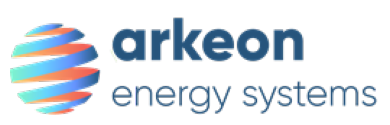

In [47]:
import os
import json
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ipywidgets as widgets
from IPython.display import Markdown, display

# ============================================================
# Configuration and Setup
# ============================================================
startdate = pd.Timestamp("2026-04-21")
enddate   = pd.Timestamp("2026-04-22")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SITEDATA_DIR = PROJECT_ROOT / "ResultsData_site"
JUMEAUNUM_DATA_DIR = PROJECT_ROOT / "ResultsData_jumeau_num"

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Vérification et validation des modèles - visualisation vs baseline

**Site :** Pervenches-Bruyères | **Système :** PAC ARKEON

In [48]:
display(Markdown(f"**Date** : {startdate_str} → {enddate_str}\n\n---"))

**Date** : 2026-04-21 → 2026-04-22

---

Acquisition (optionnel)

## 1. Importation des librairies et des données

In [49]:
# Load data files
optim_file = DATA_DIR / "input_optimisation" / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}.csv"
site_file = SITEDATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_site.csv"
jumeaunum_ref_optim_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_OPTIM.csv"
jumeaunum_ref_site_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_SITE.csv"

# try to load optimisation results, if missing create empty DataFrame
try:
    results_optim_detail = pd.read_csv(optim_file, sep=';')
except FileNotFoundError:
    print(f"optim file not found: {optim_file}")
    results_optim_detail = pd.DataFrame()

try:
    df_synthese_visu = pd.read_csv(site_file, sep=';')
except FileNotFoundError:
    print(f"site file not found: {site_file}")
    df_synthese_visu = pd.DataFrame()

try:
    df_jn_ref_optim = pd.read_csv(jumeaunum_ref_optim_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum optim file not found: {jumeaunum_ref_optim_file}")
    df_jn_ref_optim = pd.DataFrame()

try:
    df_jn_ref_site = pd.read_csv(jumeaunum_ref_site_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum site file not found: {jumeaunum_ref_site_file}")
    df_jn_ref_site = pd.DataFrame()

optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\data\input_optimisation\ResultsTable_21APR26.csv
jumeaunum optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\ResultsData_jumeau_num\ResultsTable_21APR26_JN_ref_OPTIM.csv


## 2. Visualisation : 

### 2.1. JN Ref Optim

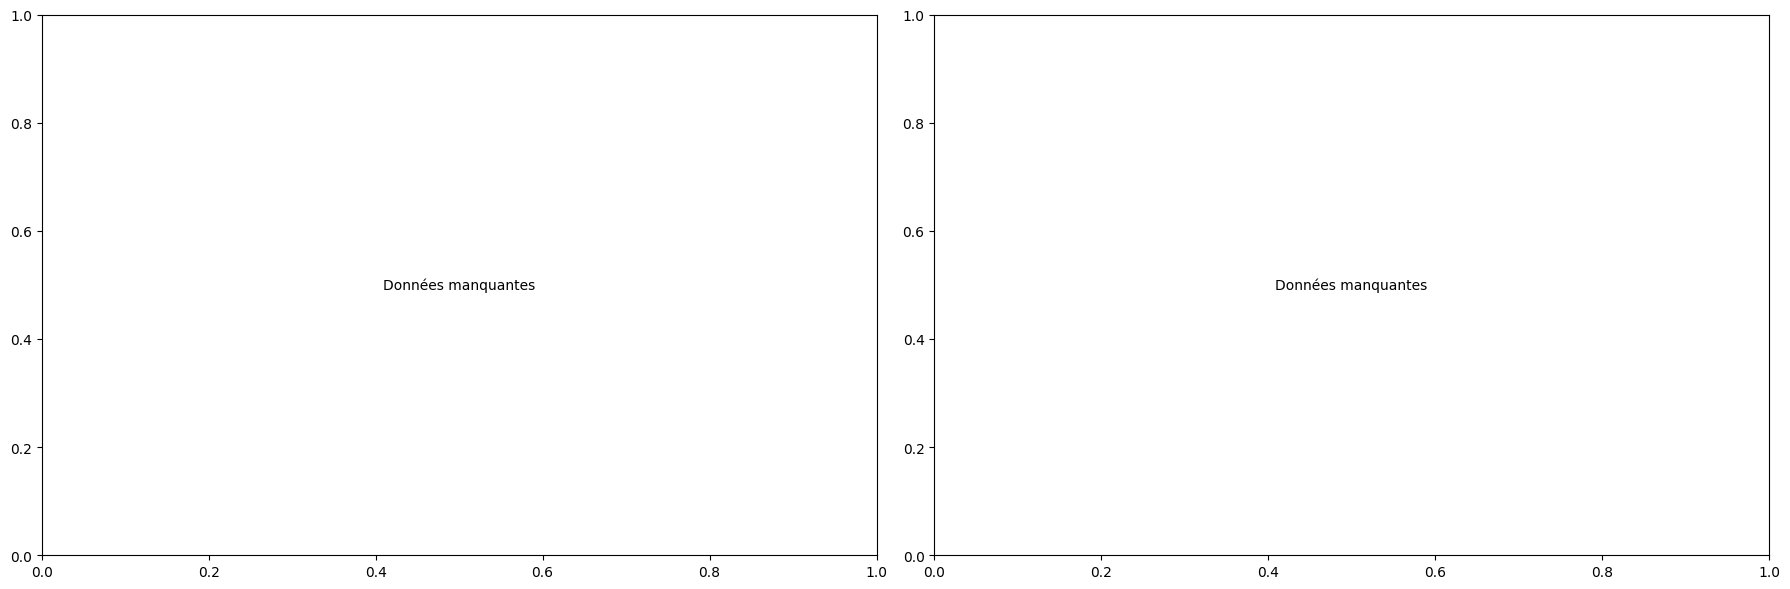

In [50]:
# --- Comparison: Elec_tot vs Elec_base and Conso vs Conso_base (JN Ref Optim) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(df_jn_ref_optim))

# ============================================================================
# GRAPHIQUE 1 : Elec_tot vs Elec_base
# ============================================================================
if not df_jn_ref_optim.empty and 'Elec_tot' in df_jn_ref_optim.columns and 'Elec_base' in df_jn_ref_optim.columns:
    ax1.plot(x, df_jn_ref_optim['Elec_tot'], marker='o', linewidth=2, label='Elec_tot', color='#6694FF')
    ax1.plot(x, df_jn_ref_optim['Elec_base'], marker='s', linewidth=2, label='Elec_base', color='#FF9166')
    
    print("--- Statistiques Elec_tot vs Elec_base ---")
    print(f"Elec_tot  - Mean: {df_jn_ref_optim['Elec_tot'].mean():.2f} kWh, "
          f"Min: {df_jn_ref_optim['Elec_tot'].min():.2f} kWh, Max: {df_jn_ref_optim['Elec_tot'].max():.2f} kWh, "
          f"Total: {df_jn_ref_optim['Elec_tot'].sum():.2f} kWh")
    print(f"Elec_base - Mean: {df_jn_ref_optim['Elec_base'].mean():.2f} kWh, "
          f"Min: {df_jn_ref_optim['Elec_base'].min():.2f} kWh, Max: {df_jn_ref_optim['Elec_base'].max():.2f} kWh, "
          f"Total: {df_jn_ref_optim['Elec_base'].sum():.2f} kWh")
    
    ax1.set_title('Comparaison Elec_tot vs Elec_base', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heure')
    ax1.set_ylabel('Energie électrique (kWh)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax1.transAxes)

# ============================================================================
# GRAPHIQUE 2 : Cost_hour vs Conso_base
# ============================================================================
if not df_jn_ref_optim.empty and 'Cost_hour' in df_jn_ref_optim.columns and 'Conso_base' in df_jn_ref_optim.columns:
    ax2.plot(x, df_jn_ref_optim['Cost_hour'], marker='o', linewidth=2, label='Cost_hour', color='#6694FF')
    ax2.plot(x, df_jn_ref_optim['Conso_base'], marker='s', linewidth=2, label='Conso_base', color='#FF9166')
    
    print("\n--- Statistiques Cost_hour vs Conso_base ---")
    print(f"Cost_hour      - Mean: {df_jn_ref_optim['Cost_hour'].mean():.2f}, "
          f"Min: {df_jn_ref_optim['Cost_hour'].min():.2f}, Max: {df_jn_ref_optim['Cost_hour'].max():.2f}, "
          f"Total: {df_jn_ref_optim['Cost_hour'].sum():.2f}")
    print(f"Conso_base - Mean: {df_jn_ref_optim['Conso_base'].mean():.2f}, "
          f"Min: {df_jn_ref_optim['Conso_base'].min():.2f}, Max: {df_jn_ref_optim['Conso_base'].max():.2f}, "
          f"Total: {df_jn_ref_optim['Conso_base'].sum():.2f}")
    
    ax2.set_title('Comparaison Cost_hour vs Conso_base', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Heure')
    ax2.set_ylabel('Coût')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### 2.2. JN Ref Site

--- Statistiques Elec_tot vs Elec_base ---
Elec_tot  - Mean: 12.86 kWh, Min: 1.08 kWh, Max: 65.07 kWh, Total: 308.53 kWh
Elec_base - Mean: 9.76 kWh, Min: 4.36 kWh, Max: 18.17 kWh, Total: 234.24 kWh

--- Statistiques Cost_hour vs Conso_base ---
Cost_hour      - Mean: 1.43, Min: 0.40, Max: 5.50, Total: 34.20
Conso_base - Mean: 1.26, Min: 0.64, Max: 2.33, Total: 30.22


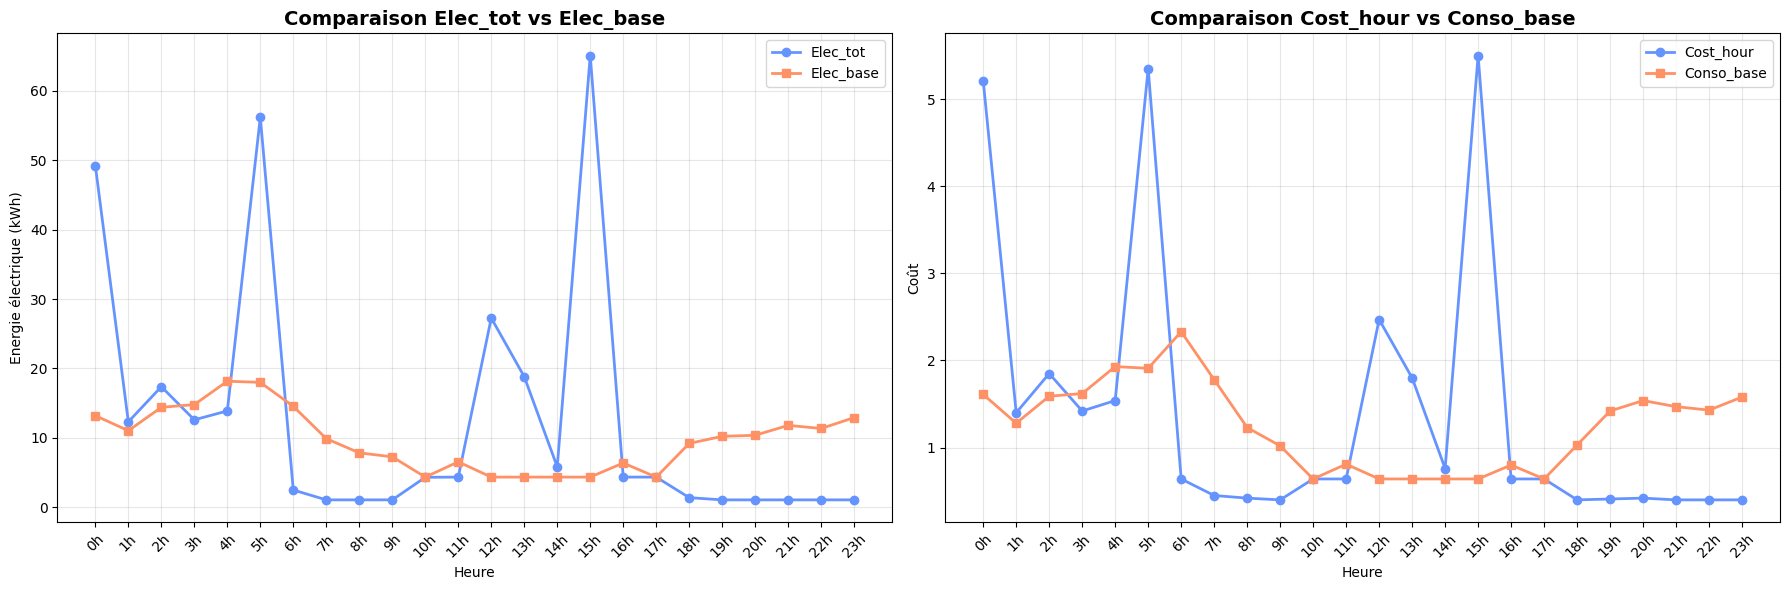

In [51]:
# --- Comparison: Elec_tot vs Elec_base and Conso vs Conso_base (JN Ref Site) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(df_jn_ref_site))

# ============================================================================
# GRAPHIQUE 1 : Elec_tot vs Elec_base
# ============================================================================
if not df_jn_ref_site.empty and 'Elec_tot' in df_jn_ref_site.columns and 'Elec_base' in df_jn_ref_site.columns:
    ax1.plot(x, df_jn_ref_site['Elec_tot'], marker='o', linewidth=2, label='Elec_tot', color='#6694FF')
    ax1.plot(x, df_jn_ref_site['Elec_base'], marker='s', linewidth=2, label='Elec_base', color='#FF9166')
    
    print("--- Statistiques Elec_tot vs Elec_base ---")
    print(f"Elec_tot  - Mean: {df_jn_ref_site['Elec_tot'].mean():.2f} kWh, "
          f"Min: {df_jn_ref_site['Elec_tot'].min():.2f} kWh, Max: {df_jn_ref_site['Elec_tot'].max():.2f} kWh, "
          f"Total: {df_jn_ref_site['Elec_tot'].sum():.2f} kWh")
    print(f"Elec_base - Mean: {df_jn_ref_site['Elec_base'].mean():.2f} kWh, "
          f"Min: {df_jn_ref_site['Elec_base'].min():.2f} kWh, Max: {df_jn_ref_site['Elec_base'].max():.2f} kWh, "
          f"Total: {df_jn_ref_site['Elec_base'].sum():.2f} kWh")
    
    ax1.set_title('Comparaison Elec_tot vs Elec_base', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heure')
    ax1.set_ylabel('Energie électrique (kWh)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax1.transAxes)

# ============================================================================
# GRAPHIQUE 2 : Cost_hour vs Conso_base
# ============================================================================
if not df_jn_ref_site.empty and 'Cost_hour' in df_jn_ref_site.columns and 'Conso_base' in df_jn_ref_site.columns:
    ax2.plot(x, df_jn_ref_site['Cost_hour'], marker='o', linewidth=2, label='Cost_hour', color='#6694FF')
    ax2.plot(x, df_jn_ref_site['Conso_base'], marker='s', linewidth=2, label='Conso_base', color='#FF9166')
    
    print("\n--- Statistiques Cost_hour vs Conso_base ---")
    print(f"Cost_hour      - Mean: {df_jn_ref_site['Cost_hour'].mean():.2f}, "
          f"Min: {df_jn_ref_site['Cost_hour'].min():.2f}, Max: {df_jn_ref_site['Cost_hour'].max():.2f}, "
          f"Total: {df_jn_ref_site['Cost_hour'].sum():.2f}")
    print(f"Conso_base - Mean: {df_jn_ref_site['Conso_base'].mean():.2f}, "
          f"Min: {df_jn_ref_site['Conso_base'].min():.2f}, Max: {df_jn_ref_site['Conso_base'].max():.2f}, "
          f"Total: {df_jn_ref_site['Conso_base'].sum():.2f}")
    
    ax2.set_title('Comparaison Cost_hour vs Conso_base', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Heure')
    ax2.set_ylabel('Coût')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### 2.3. Reel Site

--- Statistiques Elec_tot vs Elec_base ---
Elec_tot  - Mean: 13.43 kWh, Min: 1.25 kWh, Max: 40.50 kWh, Total: 322.31 kWh
Elec_base - Mean: 9.76 kWh, Min: 4.36 kWh, Max: 18.17 kWh, Total: 234.24 kWh

--- Statistiques Cost_hour vs Conso_base ---
Cost_hour      - Mean: 1.42, Min: 0.40, Max: 3.76, Total: 34.13
Conso_base - Mean: 1.26, Min: 0.64, Max: 2.33, Total: 30.22


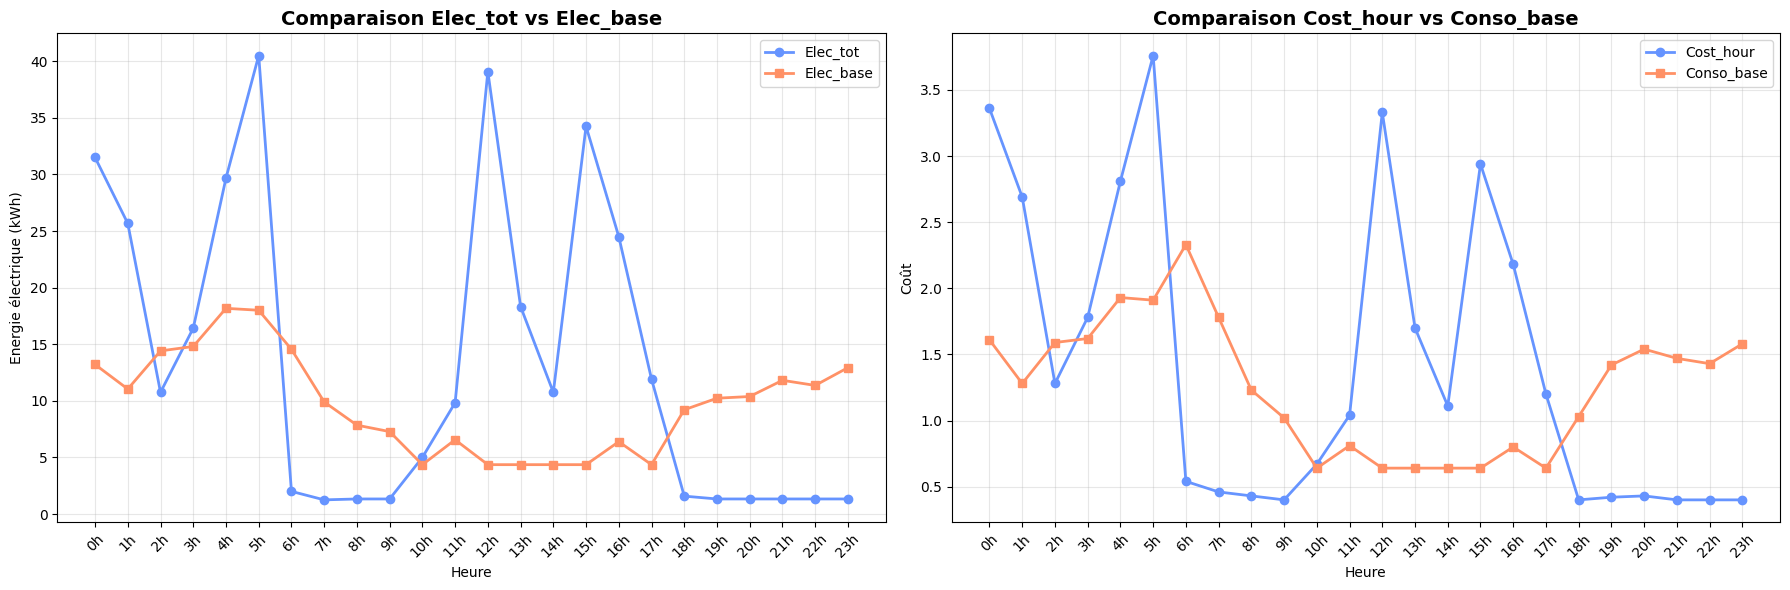

In [52]:
# --- Comparison: Elec_tot vs Elec_base and Conso vs Conso_base (Reel site) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(df_synthese_visu))

# ============================================================================
# GRAPHIQUE 1 : Elec_tot vs Elec_base
# ============================================================================
if not df_synthese_visu.empty and 'Elec_tot' in df_synthese_visu.columns and 'Elec_base' in df_synthese_visu.columns:
    ax1.plot(x, df_synthese_visu['Elec_tot'], marker='o', linewidth=2, label='Elec_tot', color='#6694FF')
    ax1.plot(x, df_synthese_visu['Elec_base'], marker='s', linewidth=2, label='Elec_base', color='#FF9166')
    
    print("--- Statistiques Elec_tot vs Elec_base ---")
    print(f"Elec_tot  - Mean: {df_synthese_visu['Elec_tot'].mean():.2f} kWh, "
          f"Min: {df_synthese_visu['Elec_tot'].min():.2f} kWh, Max: {df_synthese_visu['Elec_tot'].max():.2f} kWh, "
          f"Total: {df_synthese_visu['Elec_tot'].sum():.2f} kWh")
    print(f"Elec_base - Mean: {df_synthese_visu['Elec_base'].mean():.2f} kWh, "
          f"Min: {df_synthese_visu['Elec_base'].min():.2f} kWh, Max: {df_synthese_visu['Elec_base'].max():.2f} kWh, "
          f"Total: {df_synthese_visu['Elec_base'].sum():.2f} kWh")
    
    ax1.set_title('Comparaison Elec_tot vs Elec_base', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heure')
    ax1.set_ylabel('Energie électrique (kWh)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax1.transAxes)

# ============================================================================
# GRAPHIQUE 2 : Cost_hour vs Conso_base
# ============================================================================
if not df_synthese_visu.empty and 'Cost_hour' in df_synthese_visu.columns and 'Conso_base' in df_synthese_visu.columns:
    ax2.plot(x, df_synthese_visu['Cost_hour'], marker='o', linewidth=2, label='Cost_hour', color='#6694FF')
    ax2.plot(x, df_synthese_visu['Conso_base'], marker='s', linewidth=2, label='Conso_base', color='#FF9166')
    
    print("\n--- Statistiques Cost_hour vs Conso_base ---")
    print(f"Cost_hour      - Mean: {df_synthese_visu['Cost_hour'].mean():.2f}, "
          f"Min: {df_synthese_visu['Cost_hour'].min():.2f}, Max: {df_synthese_visu['Cost_hour'].max():.2f}, "
          f"Total: {df_synthese_visu['Cost_hour'].sum():.2f}")
    print(f"Conso_base - Mean: {df_synthese_visu['Conso_base'].mean():.2f}, "
          f"Min: {df_synthese_visu['Conso_base'].min():.2f}, Max: {df_synthese_visu['Conso_base'].max():.2f}, "
          f"Total: {df_synthese_visu['Conso_base'].sum():.2f}")
    
    ax2.set_title('Comparaison Cost_hour vs Conso_base', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Heure')
    ax2.set_ylabel('Coût')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

### 2.4. Optim

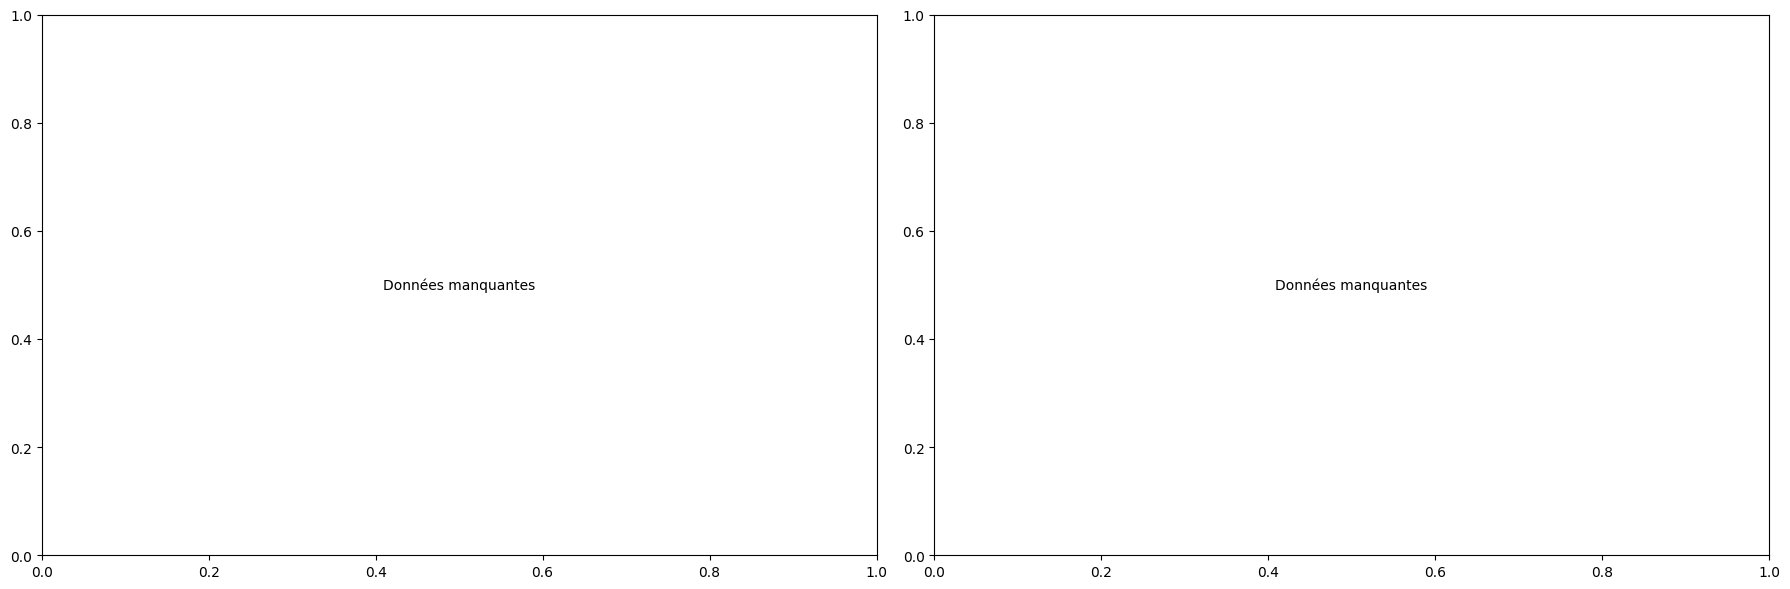

In [53]:
# --- Comparison: Elec_tot vs Elec_base and Conso vs Conso_base (Optim) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(results_optim_detail))

# ============================================================================
# GRAPHIQUE 1 : Elec_tot vs Elec_base
# ============================================================================
if not results_optim_detail.empty and 'Elec_tot' in results_optim_detail.columns and 'Elec_base' in results_optim_detail.columns:
    ax1.plot(x, results_optim_detail['Elec_tot'], marker='o', linewidth=2, label='Elec_tot', color='#6694FF')
    ax1.plot(x, results_optim_detail['Elec_base'], marker='s', linewidth=2, label='Elec_base', color='#FF9166')
    
    print("--- Statistiques Elec_tot vs Elec_base ---")
    print(f"Elec_tot  - Mean: {results_optim_detail['Elec_tot'].mean():.2f} kWh, "
          f"Min: {results_optim_detail['Elec_tot'].min():.2f} kWh, Max: {results_optim_detail['Elec_tot'].max():.2f} kWh, "
          f"Total: {results_optim_detail['Elec_tot'].sum():.2f} kWh")
    print(f"Elec_base - Mean: {results_optim_detail['Elec_base'].mean():.2f} kWh, "
          f"Min: {results_optim_detail['Elec_base'].min():.2f} kWh, Max: {results_optim_detail['Elec_base'].max():.2f} kWh, "
          f"Total: {results_optim_detail['Elec_base'].sum():.2f} kWh")
    
    ax1.set_title('Comparaison Elec_tot vs Elec_base', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heure')
    ax1.set_ylabel('Energie électrique (kWh)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax1.transAxes)

# ============================================================================
# GRAPHIQUE 2 : Cost_hour vs Conso_base
# ============================================================================
if not results_optim_detail.empty and 'Cost_hour' in results_optim_detail.columns and 'Conso_base' in results_optim_detail.columns:
    ax2.plot(x, results_optim_detail['Cost_hour'], marker='o', linewidth=2, label='Cost_hour', color='#6694FF')
    ax2.plot(x, results_optim_detail['Conso_base'], marker='s', linewidth=2, label='Conso_base', color='#FF9166')
    
    print("\n--- Statistiques Cost_hour vs Conso_base ---")
    print(f"Cost_hour      - Mean: {results_optim_detail['Cost_hour'].mean():.2f}, "
          f"Min: {results_optim_detail['Cost_hour'].min():.2f}, Max: {results_optim_detail['Cost_hour'].max():.2f}, "
          f"Total: {results_optim_detail['Cost_hour'].sum():.2f}")
    print(f"Conso_base - Mean: {results_optim_detail['Conso_base'].mean():.2f}, "
          f"Min: {results_optim_detail['Conso_base'].min():.2f}, Max: {results_optim_detail['Conso_base'].max():.2f}, "
          f"Total: {results_optim_detail['Conso_base'].sum():.2f}")
    
    ax2.set_title('Comparaison Cost_hour vs Conso_base', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Heure')
    ax2.set_ylabel('Coût')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Données manquantes', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()